## Lecture 13 Evaluating the thermal wind relationship across Drake Passage in MPAS-Ocean

In [392]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [393]:
#Packages 
import numpy as np
import xarray as xr
import cmocean.cm as cmo
import matplotlib.pyplot as plt
import mpas_tools

from geometric_features import GeometricFeatures
from geometric_features import read_feature_collection

from mpas_tools.mesh.mask import compute_mpas_region_masks
from mpas_tools.parallel import create_pool
from mpas_tools.io import write_netcdf

import geojson
import json
import mosaic
import os.path
import mpasregions.sections as mps
import gsw
import warnings 
import glob
from xgcm import Grid

In [394]:
# open mesh and filepaths
# global mesh
mesh_path = '/global/cfs/projectdirs/e3sm/inputdata/ocn/mpas-o/EC30to60E2r2/ocean.EC30to60E2r2.210210.nc'
mesh = xr.open_dataset(mesh_path)
mesh = mesh.assign_coords({
"VertexID": xr.DataArray(mesh.indexToVertexID, dims=('nVertices',)),
})

# global data
bmm_filepath = '/pscratch/sd/b/bmoorema/run_001_062/'
# dso = xr.open_dataset(bmm_filepath + '20210421_sim7_CORE_60to30E2r2.mpaso.hist.am.timeSeriesStatsMonthly.0063-12-01.nc', decode_timedelta=True)

# open base mask that we will fill with 0s according to the original mask (this new mask will contain cells PLUS their corresponding edges and vertices)
# base_mask = xr.open_dataset('./mpas-o_EC30to60_global_base_mask.nc')


In [395]:
# open datasets with just the variables that we want

months = ['01','02','03','04','05','06','07','08','09','10','11','12']
ds_list = []

prefix = '20210421_sim7_CORE_60to30E2r2.mpaso.hist.am.timeSeriesStats'

year = 3 # int
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for i in range(0,12):
        month = months[i]
        file = prefix + f'Monthly.{str(year).zfill(4)}-{month}-01.nc'
        file_glob = glob.glob(file)
        ds = xr.open_dataset(bmm_filepath + file)[['xtime_startMonthly','timeMonthly_avg_normalVelocity','timeMonthly_avg_potentialDensity','timeMonthly_avg_layerThickness',
                                                   'nCells','nEdges','nVertLevels','nVertLevelsP1']]
        ds_xtime_startMonthly = ds.swap_dims({'Time':'xtime_startMonthly'})
        ds_list.append(ds_xtime_startMonthly)

dss = xr.concat(ds_list,dim='xtime_startMonthly')
ds = mps.add_grid_info_coords(mesh,dss)

In [396]:
# set up descriptor for plotting 

mesh.attrs['is_periodic'] = 'YES'
mesh.attrs['x_period'] = 360
mesh.attrs['y_period'] = 0.0

descriptor = mosaic.Descriptor(mesh,use_latlon=False)

### Create a meridional section that crosses the Drake Passage (do some literature review to see what is standard; e.g. from Becki Beadling's papers).
"Closest grid cells to 69$^\circ$W" ([Beadling et al, 2020](https://journals.ametsoc.org/view/journals/clim/33/15/jcliD190970.xml))

$\uparrow$ I abandoned this because my code is broken. I tried to kind of get a similar transect, but it is not that close to 69S...

In [397]:
# this is because the calculate_transects_multiple_pts function doesn't really work
# use three points to create a closed loop (idk how to calculate transport through a transect 
# since there is no region mask defined by two points of a transect
lons = np.array([292,296, 294, ])
lats = np.array([-55,-55, -67.17])

target_coords = np.linspace(1022,1029,100)

# edges, vertices = mps.calculate_transects_multiple_pts(lons,lats,ds)



In [398]:
vertices = np.array(
[377493, 266182, 96468, 139205, 408278, 3521, 12939, 363527, 467517,
 419751, 68335, 151655, 161361, 365265, 370908, 474745, 87585, 374980,
 135889, 204145, 104636, 466908, 18047, 372634, 65963, 14159, 21666,
 346925, 274497, 193521, 398998, 340299, 372002, 40577, 11790, 179118,
 175651, 300733, 401842, 35696, 125204, 46534, 41526, 26131, 69383,
 146780, 105347, 221619, 204394, 447786, 134879, 457478, 315300, 118511,
 113371, 400773, 37380, 12770, 231963, 111076, 57003, 226967, 60180,
 28867, 258172, 324685, 249984, 351358, 76804, 217776, 383827, 95501,
 254236, 385328, 354442, 57910, 105001, 4221, 192107, 145837, 394006,
 8243, 341840, 38485, 76844, 302561, 373188, 127046, 465928, 429921,
 466439, 331215, 151348, 46828, 350572, 446418, 222342, 103707, 103686,
 162996, 2045, 182922, 2360, 212733, 47379, 481398, 470832, 370450,
 322321, 416934, 165826, 476398, 251750, 63281, 192687, 419642, 351941])
 # 24707, 225709, 257052, 455603, 327141, 386318, 257008, 217024, 171355,
 # 282062, 162895, 154153, 466110, 280192, 455954, 254801, 360884, 98876,
 # 371767, 119492, 353129, 235738]
#)


In [399]:
# fig, ax = plt.subplots(nrows=1,ncols=1,constrained_layout=True,figsize=(12,7))

# mosaic.polypcolor(ax,descriptor,dsMasks.regionCellMasks.isel(nRegions=0),cmap='cool',alpha=0.5)
# c =ax.scatter(np.rad2deg(ds.lonVertex.isel(nVertices = vertices)), np.rad2deg(ds.latVertex.isel(nVertices = vertices)), c=np.arange(0,len(vertices)))

# ax.set_ylim(-75,-50)
# ax.set_xlim(285,300)

In [401]:
# next vertices are in xr indices
int_next_vertices = np.int32(vertices)
n_transect_edges = np.array([])

for i in range(0,len(int_next_vertices)-1):
    edgesOnVertex0 = ds.edgesOnVertex.isel(nVertices = int_next_vertices[i]).values
    edgesOnVertex1 = ds.edgesOnVertex.isel(nVertices = int_next_vertices[i+1]).values
    shared_edge = np.intersect1d(edgesOnVertex0, edgesOnVertex1)
    n_transect_edges = np.append(n_transect_edges, shared_edge)

xr_transect_edges = mps.n_to_xr_idx(n_transect_edges)

In [402]:
path = './'
filename = 'Drake_passage_69_9'
geojson_file_name = 'Drake passage (points closest to 69S) to calculate ACC strength'
tags = "Southern_Ocean"
author = "Kaila Uyeda"

# test_verts_lats, test_verts_lons, dsMasks = mps.transect_from_alg_create_nc(vertices, 
#                                                                                 ds, 
#                                                                                 path,
#                                                                                 filename, 
#                                                                                 geojson_file_name,
#                                                                                 tags, 
#                                                                                 author)
# xr_mask_transect_edges, xr_mask_transect_vertices, alg_edges, alg_vertices = mps.find_and_sort_transect_edges_and_vertices(ds,dsMasks)

In [403]:
# this is in lieu of the transect_from_alg_create_nc function
test_verts = vertices
# get the lats and lons of the test_verts to use for creation of a geojson file
test_verts_lats = ds.latVertex.isel(nVertices = np.int32(test_verts)) * 180/np.pi #+ 50
test_verts_lons = ds.lonVertex.isel(nVertices = np.int32(test_verts)) * 180/np.pi #+ 360

test_verts_lonslats = np.array([test_verts_lons,test_verts_lats]).T
list_test_verts_lonslats = test_verts_lonslats.tolist()

# ----------- CREATE GEOJSON FILE -----------
# check if the geojson mask file created from a transect algorithm exists
alg_filename = filename + '_transect_from_alg'

check_alg_geojson_existence = os.path.isfile(path + alg_filename + '.geojson')

if check_alg_geojson_existence == True:
    print(f'{alg_filename}.geojson exists!')
else:
    print('Creating geojson file from vertices identified with transect algorithm')
    
    transect_from_alg = {
        "type": "FeatureCollection",
        "features": [{
            "type": "Feature",
            "properties":{
                "name":geojson_file_name,
                "tags":"Labrador_Sea;Davis_Strait",
                "object":"region",
                "component":"ocean",
                "author":"Kaila Uyeda"
            },
            "geometry": {
                "coordinates":[list_test_verts_lonslats],
                "type": "Polygon"
            }
        }]
    }

    # save to a geojson file
    # with = open and then close
    # w = write mode
    
    with open(path + f'{alg_filename}.geojson','w') as f:
        geojson.dump(transect_from_alg, f, indent=2)

# ----------- CREATE NETCDF FILE -----------

# check if the .nc mask file created from a transect algorithm exists
# check if the .nc mask file created from a transect algorithm exists
check_alg_nc_existence = os.path.isfile(path + alg_filename + '.nc')

if check_alg_nc_existence:
    print(f'Opening {alg_filename}.nc as dsMasks')
    dsMasks = xr.open_dataset(path + alg_filename + '.nc')

else:
    print('Creating netcdf mask file from geojson file (vertices identified from transect algorithm)')    
    fcMask = read_feature_collection(path + alg_filename + '.geojson')
    for feat in fcMask.features:
        coords = feat['geometry']['coordinates'][0]
        # normalize 0-360 to -180-180
        coords = [[(lon + 180) % 360 - 180, lat] for lon, lat in coords]

        # ensure closed
        if coords[0] != coords[-1]:
            coords.append(coords[0])

        # make polygon and envorce CCW
        poly = geom.Polygon(coords)
        if not poly.exterior.is_ccw:
            coords = coords[::-1]

        feat['geometry']['coordinates'][0] = coords
        
    # Compute region masks
    pool = None
    dsMasks = compute_mpas_region_masks(ds, fcMask, maskTypes=('cell',), pool=pool)

    # Write to netcdf
    dsMasks.to_netcdf(path + alg_filename + '.nc', format='NETCDF4', mode='w')
    dsMasks = xr.open_dataset(path + alg_filename + '.nc')

    print(f'{alg_filename}.nc created and opened as dsMasks')


Drake_passage_69_9_transect_from_alg.geojson exists!
Opening Drake_passage_69_9_transect_from_alg.nc as dsMasks


In [405]:
alg_edges_raw, alg_vertices_raw = mps.find_and_sort_transect_edges_and_vertices(ds,dsMasks)

[ 16446.  30690.  37991.  62396.  67428.  69273.  69279.  69280.  70773.
  78584.  78585.  80361.  80362. 107594. 114066. 114072. 132963. 136285.
 145421. 145422. 145424. 156305. 157830. 159975. 163835. 170982. 194055.
 197386. 197387. 206698. 206702. 206704. 212879. 216280. 220568. 221420.
 221747. 230266. 234085. 244486. 246902. 249123. 253194. 262863. 262867.
 268468. 269687. 271434. 276297. 277116. 285619. 294841. 295313. 312458.
 313785. 325139. 328168. 328176. 328183. 330254. 334654. 334821. 355281.
 364008. 367801. 373321. 381440. 384248. 392173. 409204. 419209. 428185.
 431318. 438475. 439358. 440273. 446351. 447312. 449657. 455722. 476244.
 477168. 494872. 495566. 499780. 499961. 509735. 509914. 512698. 513592.
 515031. 515033. 516581. 519993. 520264. 525222. 527833. 538218. 540451.
 564880. 564882. 566121. 582811. 613740. 614394. 614836. 615177. 624157.
 627000. 639296. 639304. 639305. 639309. 639761. 645138. 678216. 691058.
 691673. 706970.]


(285.0, 300.0)

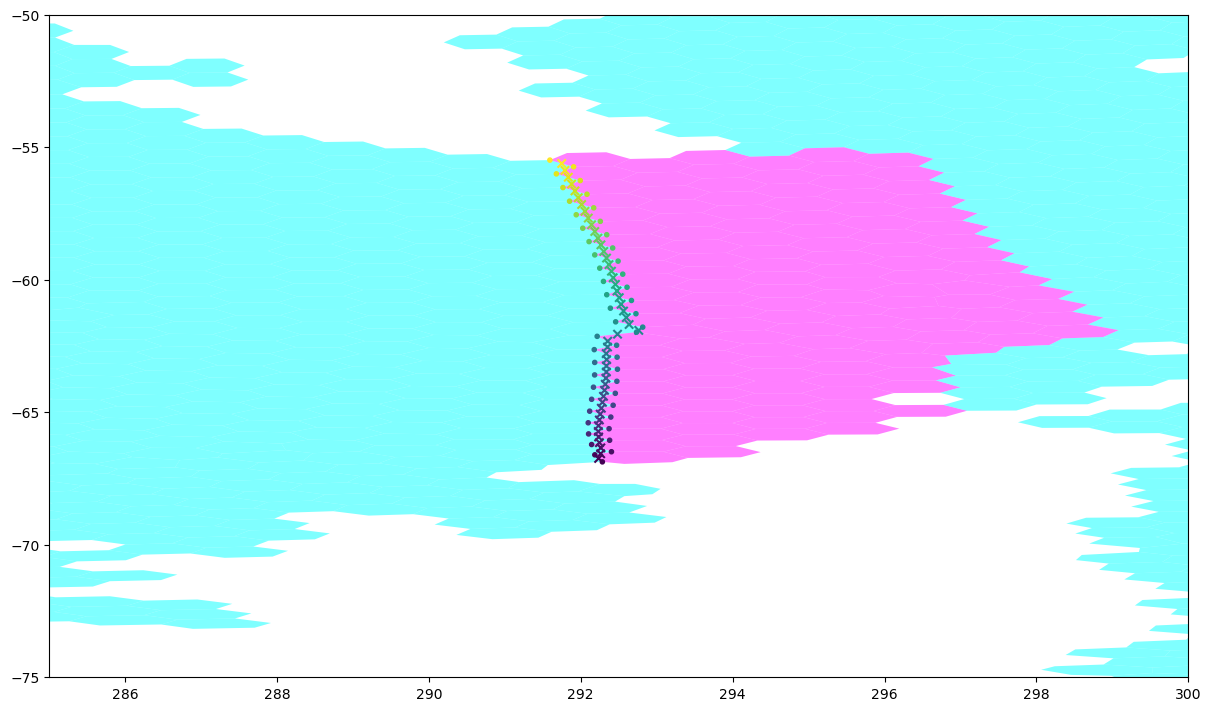

In [406]:
fig, ax = plt.subplots(nrows=1,ncols=1,constrained_layout=True,figsize=(12,7))

mosaic.polypcolor(ax,descriptor,dsMasks.regionCellMasks.isel(nRegions=0),cmap='cool',alpha=0.5)
c =ax.scatter(np.rad2deg(ds.lonVertex.isel(nVertices = alg_vertices_raw[26:75])), np.rad2deg(ds.latVertex.isel(nVertices = alg_vertices_raw[26:75])), c=np.arange(0,len(alg_vertices_raw[26:75])),marker='.')
ax.scatter(np.rad2deg(ds.lonEdge.isel(nEdges = alg_edges_raw[27:75])), np.rad2deg(ds.latEdge.isel(nEdges = alg_edges_raw[27:75])), c=np.arange(0,len(alg_edges_raw[27:75])),marker='x')


ax.set_ylim(-75,-50)
ax.set_xlim(285,300)

In [407]:
alg_edges = alg_edges_raw[27:75]
alg_vertices = alg_vertices_raw[26:75]

xr_cellsOnTransectEdges , dss_transect_edges = mps.format_transect_data(ds, alg_edges)
print('format_transect_data function gives normalVelocity between ', dss_transect_edges.timeMonthly_avg_normalVelocity.min().values , ' and ' , dss_transect_edges.timeMonthly_avg_normalVelocity.max().values)
dss_transect_edges_vIM = mps.calculate_velo_into_mask(dss_transect_edges, xr_cellsOnTransectEdges, ds, dsMasks, alg_edges) 



print('calculate_velo_into_mask function gives normalVelocity between ', dss_transect_edges_vIM.timeMonthly_avg_normalVelocity.min().values, ' and ', dss_transect_edges_vIM.timeMonthly_avg_normalVelocity.max().values)
print('calculate_velo_into_mask function gives veloIntoMask between ', dss_transect_edges_vIM.veloIntoMask.min().values, ' and ', dss_transect_edges_vIM.veloIntoMask.max().values)

format_transect_data function gives normalVelocity between  -0.3664512038230896  and  0.3658367991447449
calculate_velo_into_mask function gives normalVelocity between  -0.3664512038230896  and  0.3658367991447449
calculate_velo_into_mask function gives veloIntoMask between  -0.07753249257802963  and  0.3664512038230896


In [408]:
# in lieu of calculate_transport_into_mask
ds_transect_edges = dss_transect_edges_vIM

ds_transect_edges['timeMonthly_avg_layerThickness_Edge'] = ds_transect_edges.timeMonthly_avg_layerThickness.mean(dim='TWO')

# get the edge length for all edges in transect
ds_transect_edges_dv = ds_transect_edges.dvEdge

# calculate the cross-sectional area of the transect by multiplying the layer-thickness of the edge by the length of the edge
transect_area = ds_transect_edges.timeMonthly_avg_layerThickness_Edge * ds_transect_edges_dv

transport = transect_area * ds_transect_edges.veloIntoMask / 10**6
ds_transect_edges['transportIntoMask_Sv'] = transport

In [409]:
# in lieu of transport_in_density_coords
# now that we have transport calculated using an aaverage of the TWO cells sitting on nEdges,
# we can do an ffill to replace all these nans with potentialDensity values of the last ocean cell above them
# this allows us to do an intperolation followed by an xgcm transform to get transport by density class
ds_transect_edges['timeMonthly_avg_potentialDensity_Edge'] = ds_transect_edges.timeMonthly_avg_potentialDensity.ffill(dim='nVertLevels',
                                                                                                                     limit=1
                                                                                                                     ).mean(dim='TWO')

# interpolate the potential density values onto nVertLevelsP1 coordinates
# create an xgcm grid
grid = Grid(ds_transect_edges, coords={'Z':{'center':'nVertLevels','outer':'nVertLevelsP1'}},periodic=False,autoparse_metadata=False)

# interpolate
ds_transect_edges['timeMonthly_avg_potentialDensity_EdgeP1'] = grid.interp(ds_transect_edges.timeMonthly_avg_potentialDensity_Edge,
                                                                           'Z',
                                                                           boundary='extend'
                                                                          )

# transform
transport_transformed_cons = grid.transform(ds_transect_edges.transportIntoMask_Sv,
                                            'Z',
                                            target_coords,
                                            method='conservative',
                                            target_data = ds_transect_edges.timeMonthly_avg_potentialDensity_EdgeP1)

In [410]:
target_coords = np.linspace(1026,1028.2,100)
dss_transect_edges_vIM, transport_transformed_cons = mps.transport_in_density_space_from_ds(ds,alg_edges, dsMasks, target_coords)

This honestly makes zero sense. Why would there be positive transport (i.e., into the mask at this transect). Water should be moved OUT of the mask because the ACC moves east. 

There should be negative transport through the transect. 

Text(0.5, 0.98, 'Eastward transport through Drake Passage (2009 yearly average)')

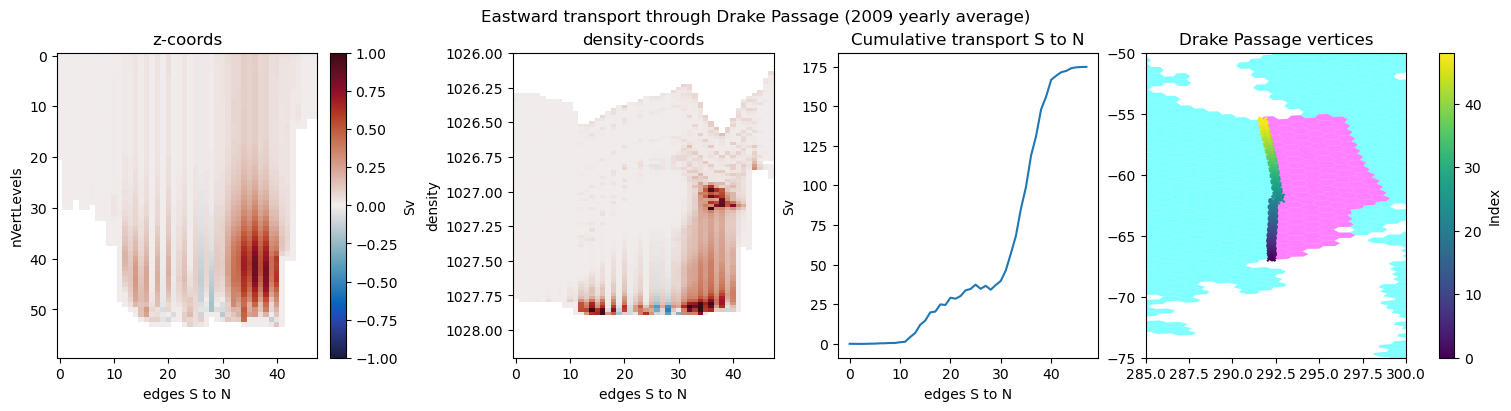

In [411]:
fig,ax = plt.subplots(nrows=1,ncols=4,constrained_layout=True,figsize=(15,4))

xr_transect_edges = np.int32(xr_transect_edges)

(dss_transect_edges_vIM.transportIntoMask_Sv).mean(dim=['xtime_startMonthly','TWO']).swap_dims({'nEdges':'transect_edgesOrdered'}).plot(y='nVertLevels', ax=ax[0],
                                                                                                                                     vmin=-1,vmax=1,cmap=cmo.balance,cbar_kwargs={'label':'Sv'})
ax[0].invert_yaxis()
ax[0].set_title('z-coords')
ax[0].set_xlabel('edges S to N')

# multiply by -1 because we want the transport OUT of the mask...
(transport_transformed_cons).mean(dim=['xtime_startMonthly','TWO']).swap_dims({'nEdges':'transect_edgesOrdered'}).plot(y='timeMonthly_avg_potentialDensity_EdgeP1', ax=ax[1],
                                                                                                                    vmin=-1,vmax=1,cmap=cmo.balance,add_colorbar=False)
ax[1].invert_yaxis()
ax[1].set_title('density-coords')
ax[1].set_ylabel('density')
ax[1].set_xlabel('edges S to N')

transport_transformed_cons.mean(dim=['xtime_startMonthly','TWO']).sum('timeMonthly_avg_potentialDensity_EdgeP1').swap_dims({'nEdges':'transect_edgesOrdered'}).cumsum('transect_edgesOrdered').plot(ax=ax[2])
ax[2].set_title('Cumulative transport S to N')
ax[2].set_ylabel('Sv')
ax[2].set_xlabel('edges S to N')

mosaic.polypcolor(ax[3],descriptor,dsMasks.regionCellMasks.isel(nRegions=0),cmap='cool',alpha=0.5)
c =ax[3].scatter(np.rad2deg(ds.lonVertex.isel(nVertices = alg_vertices_raw[26:75])), np.rad2deg(ds.latVertex.isel(nVertices = alg_vertices_raw[26:75])), c=np.arange(0,len(alg_vertices_raw[26:75])),marker='.')
ax[3].scatter(np.rad2deg(ds.lonEdge.isel(nEdges = alg_edges_raw[27:75])), np.rad2deg(ds.latEdge.isel(nEdges = alg_edges_raw[27:75])), c=np.arange(0,len(alg_edges_raw[27:75])),marker='x')


ax[3].set_ylim(-75,-50)
ax[3].set_xlim(285,300)
fig.colorbar(c,ax=ax[3],label='Index')
ax[3].set_title('Drake Passage vertices')

fig.suptitle('Eastward transport through Drake Passage (2009 yearly average)')

## 2) Sample the eastward normal transport across this section, averaged over several years; take the vertical partial derivative to diagnose the time-mean resolved thermal wind shear.
>- It is too much for me to currently change my code and sample over multiple years. I am chopped.

In [412]:
u_transport_raw = dss_transect_edges_vIM.transportIntoMask_Sv.mean(dim=['xtime_startMonthly','TWO'])
u_transport_raw = - dss_transect_edges_vIM.veloIntoMask.mean(dim=['xtime_startMonthly','TWO']) 
dz = dss_transect_edges_vIM.timeMonthly_avg_layerThickness.mean('xtime_startMonthly')


In [413]:
# interpolate zonal transport onto nVertLevelsP1
u_transport_P1 = grid.interp(u_transport_raw,axis='Z',boundary='extend')

# take thet difference between the u transport valuesP1 so that they now sit on nVertLevels
du_transport = grid.diff(u_transport_P1,axis='Z')

# calculate dz
dz = dss_transect_edges_vIM.timeMonthly_avg_layerThickness.mean(dim=['xtime_startMonthly','TWO'])

# calculate du/dz
dudz = du_transport/dz

Text(0.5, 1.0, 'Vertical shear in zonal ACC: $\\frac{\\partial u}{\\partial z}$')

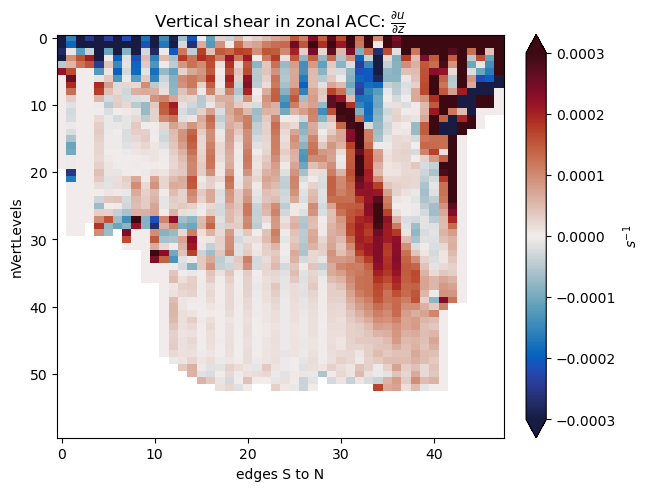

In [414]:
fig,ax = plt.subplots(nrows=1,ncols=1,constrained_layout=True)
dudz.swap_dims({'nEdges':'transect_edgesOrdered'}).plot(y='nVertLevels',cmap=cmo.balance,cbar_kwargs={'label':'$s^{-1}$'},
                                                       vmin=-0.0003,vmax=0.0003)
                                                    
ax.invert_yaxis()
ax.set_xlabel('edges S to N')
ax.set_title('Vertical shear in zonal ACC: $\\frac{\\partial u}{\\partial z}$')

## 3) Sample the seawater density along the same section, averaged over the same time period; take a partial derivative in the along-section direction and divide by the Coriolis parameter to estimate the time-mean geostrophic wind shear.

In [415]:
# get the difference in latitude between each value
# forward difference

latEdge_deg = np.rad2deg(dss_transect_edges_vIM.latEdge)

latEdge_diffs = np.array([])
for i in range(0,len(dss_transect_edges_vIM.latEdge)-1):
    latEdge_diff = mps.distance_on_unit_sphere(0,latEdge_deg[i+1], 0, latEdge_deg[i])
    latEdge_diffs = np.append(latEdge_diffs, latEdge_diff)

dy = latEdge_diffs
dy_array = dy[:,None] * np.ones((1,60))
dy_da = xr.DataArray(dy_array, dims=['nEdges','nVertLevels'])

# get difference in density between each value in the y-direction
drho = dss_transect_edges_vIM.timeMonthly_avg_potentialDensity_Edge.mean(dim='xtime_startMonthly').diff('nEdges')

# get derivative
drhody = drho/dy_da 

# calculate geostrophic wind shear estimate by dividing by coriolis
geos_wind_from_density = drhody * 9.81 / (drhody.fEdge * 1000)

Text(0.5, 1.0, 'geostrophic wind shear: $\\frac{\\partial \\rho}{\\partial y} \\frac{g}{f \\rho_0}$')

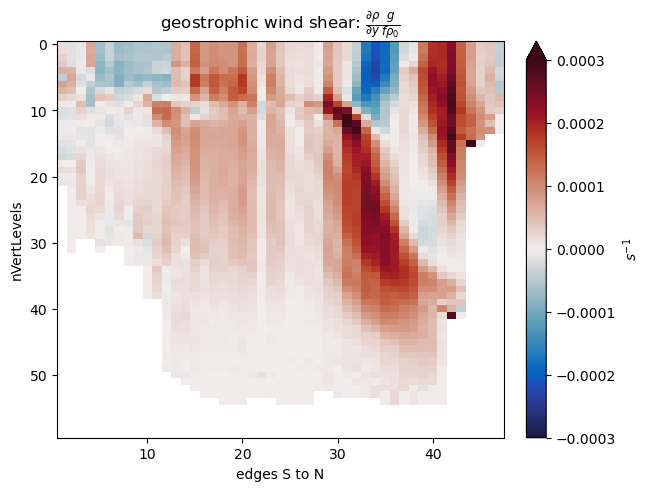

In [416]:
fig,ax = plt.subplots(nrows=1,ncols=1,constrained_layout=True)
geos_wind_from_density.swap_dims({'nEdges':'transect_edgesOrdered'}).plot(y='nVertLevels',cmap = cmo.balance,cbar_kwargs={'label':'$s^{-1}$'},
                                                                         vmin=-0.0003,vmax=0.0003)
                                                                         
                                                                         
ax.invert_yaxis()
ax.set_xlabel('edges S to N')
ax.set_title('geostrophic wind shear: $\\frac{\\partial \\rho}{\\partial y} \\frac{g}{f \\rho_0}$')